In [1]:
%load_ext autoreload
%autoreload 2

In [109]:
%load_ext viztracer

In [2]:
import os
import sys
import warnings

if '../' not in sys.path:
    sys.path.append('../')

from functools import partial
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

from mcp_boltzmann import annihilation as ann
from mcp_boltzmann.boltzmann import EMMDMBoltzmann
import mcp_boltzmann.sm as sm

warnings.filterwarnings("ignore")

plt.style.use('../input/physrev.mplstyle')
plt.rcParams['figure.dpi'] = "300"

In [3]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

In [4]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

### EMMDM model parameters

In [5]:
shelton_Q_mass_027 = load_csv('../input/fig/2206.13530_fig3_DNE_027.csv')
shelton_Q_of_M = interp1d(shelton_Q_mass_027[0], shelton_Q_mass_027[1])

In [6]:
MeV = 1.0
GeV = 1.0e3

In [158]:
R = 3
m_chi = 0.001*MeV
yprime = 0.1
Q = 1e-4

In [159]:
M_s = R*m_chi
M_f = R*m_chi

In [160]:
print(f'{Q=}')

Q=0.0001


## Annihilation Collision terms

In [161]:
from mcp_boltzmann.annihilation import load_ann_rate

_CF_ff_s_s_I = load_ann_rate(
    f'../output/rates/annihilation/anapole_R3.0/bosonic/mcp_annihilation_rate_m_{M_s:.3e}_Q_1.npz'
)

_CF_ff_f_f_I = load_ann_rate(
    f'../output/rates/annihilation/anapole_R3.0/fermionic/mcp_annihilation_rate_m_{M_f:.3e}_Q_1.npz'
)

In [162]:
#total annihilation rate from sm to dark sector
def CF_ann(T, Q):
    return Q**2*(_CF_ff_s_s_I(T) + _CF_ff_f_f_I(T))

def CF_ann_sm_ds(T_sm, T_ds, Q):
    return CF_ann(T_sm, Q) - CF_ann(T_ds, Q)

## Coulomb Scattering (ignore for now)

## Plasmon Decay

In [163]:
from mcp_boltzmann import plasma as plas
def CF_plas(T_sm, T_ds, Q):
    T_EW = 160*GeV

    #dirac fermion mcps
    pdecay_ff = np.heaviside(T_EW - T_sm, 0)*plas.C_plasmon(T_sm, T_ds, M_f, Q) 
    bdecay_ff = np.heaviside(T_sm - T_EW, 1)*plas.C_B_decay(T_sm, T_ds, M_f, Q)

    #complex scalar mcps
    pdecay_ss = np.heaviside(T_EW - T_sm, 0)*plas.C_plasmon_bosonic(T_sm, T_ds, M_s, Q) 
    bdecay_ss = np.heaviside(T_sm - T_EW, 1)*plas.C_B_decay_bosonic(T_sm, T_ds, M_s, Q)
    
    return pdecay_ff + bdecay_ff + pdecay_ss + bdecay_ss

### Z decay

In [164]:
def CF_Z_decay(T_sm, T_ds, Q):
    return plas.C_Z_decay(T_sm, T_ds, M_f, Q) + plas.C_Z_decay_bosonic(T_sm, T_ds, M_s, Q) 

In [165]:
def C_nu(T_gam, T_nu):
    return sm.DeltaRho_nue(T_gam, T_nu, 0.0) + 2*sm.DeltaRho_numu(T_gam, T_nu, 0.0)

# Setup Boltzmann equation

In [178]:
Boltz = EMMDMBoltzmann(m_chi, M_s, M_f, Q, T_nu_dec = 3.0, rtol=1e-6, atol=1e-6)
Boltz.add_colterm_EM_DS(CF_ann_sm_ds)
# Boltz.add_colterm_EM_NU(C_nu)

# Boltz.add_colterm_EM_DS(CF_scatt_sm_ds)
Boltz.add_colterm_EM_DS(CF_plas)
Boltz.add_colterm_EM_DS(CF_Z_decay)

In [167]:
T_gamma_0 = max(100*M_s, 20)
T_nu_0 = T_gamma_0

In [168]:
T_DS_0 = Boltz.guess_initial_dark_temp(T_gamma_0)
print(T_DS_0)
if (np.isclose(T_DS_0, T_gamma_0)):
    T_DS_0 = T_gamma_0 
else:
    T_DS_0 = 1e-2*T_gamma_0 
print(f'{T_DS_0=:.3e}')

# T_DS_0 = 0.5*T_gamma_0

20.0
T_DS_0=2.000e+01


In [169]:
sol_sm = Boltz.solve_boltzmann_eq_SM(10.0, 10.0)

time_sm = sol_sm[0]
T_gam_sm = sol_sm[1]
T_nu_sm = sol_sm[2]
sf_sm = sol_sm[3]

Boltz.N_eff_SM(T_gam_sm[-1], T_nu_sm[-1])

array(3.0062896)

In [179]:
%%time
sol_bsm = Boltz.solve_boltzmann_eq(T_gamma_0, T_nu_0, T_DS_0)

time_bsm = sol_bsm[0]
T_gam_bsm = sol_bsm[1]
T_nu_bsm = sol_bsm[2]
T_dark_bsm = sol_bsm[3]
sf_bsm = sol_bsm[4]

CPU times: user 4.92 s, sys: 18.7 ms, total: 4.94 s
Wall time: 4.93 s


## Neff

In [171]:
N_eff_bsm = Boltz.N_eff(T_gam_bsm[-1], T_nu_bsm[-1], T_dark_bsm[-1])
N_eff_sm = Boltz.N_eff_SM(T_gam_sm[-1], T_nu_sm[-1])

DeltaN_eff_dso = Boltz.Delta_Neff_ds_only(T_gam_bsm[-1], T_dark_bsm[-1])
Delta_Neff = N_eff_bsm - N_eff_sm 

In [172]:
print(f'{N_eff_sm=}')
print(f'{N_eff_bsm=}')
print(f'{Delta_Neff=}')

print(f'{DeltaN_eff_dso=}')

print(f'{T_dark_bsm[-1]/T_gam_bsm[-1]=}')
print(f'{T_nu_bsm[-1]/T_gam_bsm[-1]=}')

print(f'{T_gam_bsm[-1]/T_gam_sm[-1]=}')

N_eff_sm=array(3.0062896)
N_eff_bsm=array([41.70786488])
Delta_Neff=array([38.70157529])
DeltaN_eff_dso=array([33.67837894])
T_dark_bsm[-1]/T_gam_bsm[-1]=1.645201452803186
T_nu_bsm[-1]/T_gam_bsm[-1]=0.9129508358995501
T_gam_bsm[-1]/T_gam_sm[-1]=0.6378208230657153


In [119]:
T_dark_bsm[-1]

2.4471695084375376e-05

## Temperature Evolution

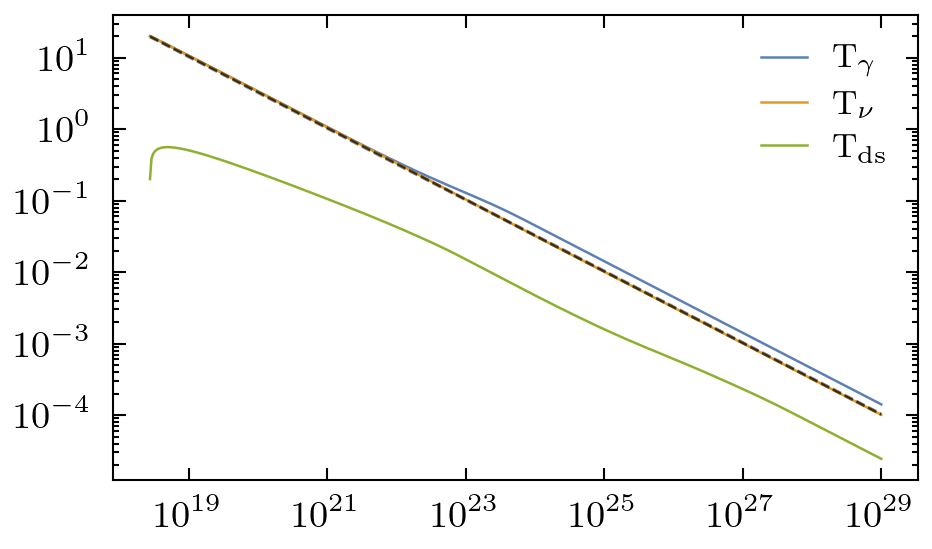

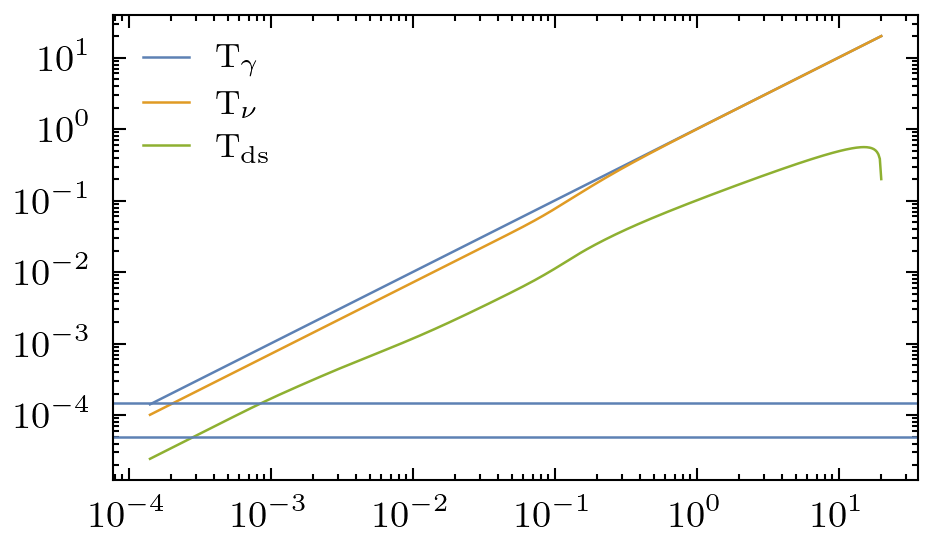

In [120]:
plt.plot(time_bsm, T_gam_bsm, label=r'T$_\gamma$')
plt.plot(time_bsm, T_nu_bsm, label=r'T$_{\nu}$')
plt.plot(time_bsm, T_dark_bsm, label=r'T$_{\rm ds}$')

plt.plot(time_bsm, T_gam_bsm[0]*np.sqrt(time_bsm[0]/time_bsm), linestyle='dashed', color='black', alpha=0.5)
plt.plot(time_bsm, T_nu_bsm[-1]*np.sqrt(time_bsm[-1]/time_bsm), linestyle='dashed', color='black', alpha=0.5)

plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()


plt.plot(T_gam_bsm, T_gam_bsm, label=r'T$_\gamma$')
plt.plot(T_gam_bsm, T_nu_bsm, label=r'T$_{\nu}$')
plt.plot(T_gam_bsm, T_dark_bsm, label=r'T$_{\rm ds}$')
plt.axhline(m_chi/20)
plt.axhline(R*m_chi/20)


plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()


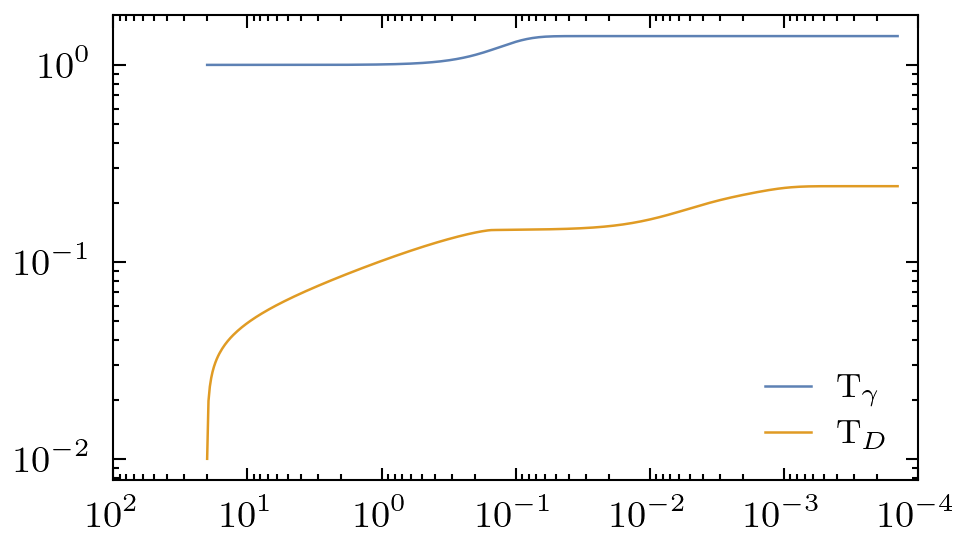

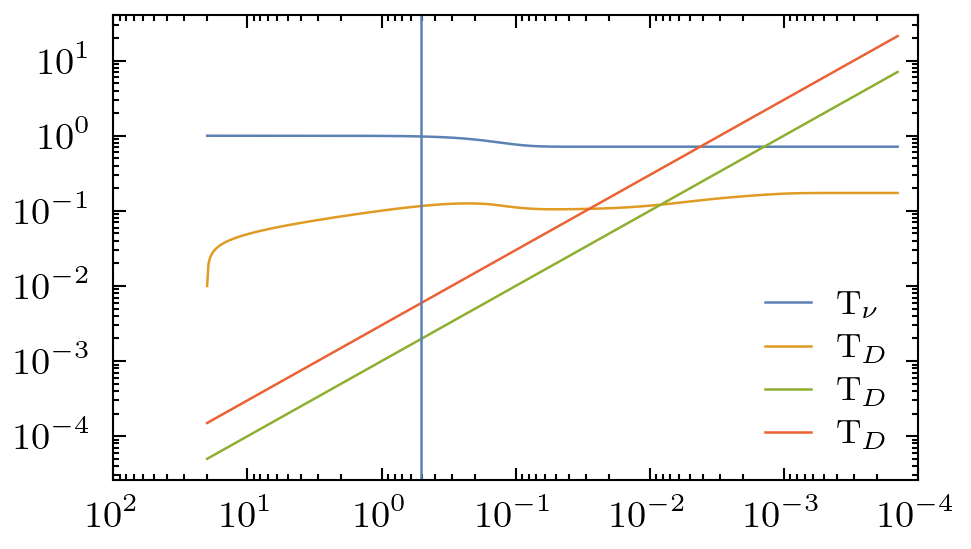

In [121]:
# T_scale = T_gam_bsm[-1]*np.sqrt(time_bsm[-1]/time_bsm)

plt.plot(T_gam_bsm, T_gam_bsm/T_nu_bsm, label=r'T$_\gamma$')
plt.plot(T_gam_bsm, T_dark_bsm/T_nu_bsm, label=r'T$_D$')
# plt.plot(T_gam_sm, T_gam_sm/T_nu_sm)
# plt.plot(time_bsm, T_nu_bsm, label=r'T$_{\nu}$')
# plt.plot(time_bsm, T_dark_bsm, label=r'T$_{\rm ds}$')


plt.yscale('log')
plt.xscale('log')

plt.xlim(1e-4, 100)
# plt.ylim(8e-1, 2)

plt.gca().invert_xaxis()

plt.legend()

plt.show()

plt.plot(T_gam_bsm, T_nu_bsm/T_gam_bsm, label=r'T$_\nu$')
plt.plot(T_gam_bsm, T_dark_bsm/T_gam_bsm, label=r'T$_D$')

plt.plot(T_gam_bsm, m_chi/T_gam_bsm, label=r'T$_D$')
plt.plot(T_gam_bsm, R*m_chi/T_gam_bsm, label=r'T$_D$')
# plt.plot(T_gam_sm, T_gam_sm/T_nu_sm)
# plt.plot(time_bsm, T_nu_bsm, label=r'T$_{\nu}$')
# plt.plot(time_bsm, T_dark_bsm, label=r'T$_{\rm ds}$')


plt.yscale('log')
plt.xscale('log')

plt.xlim(1e-4, 100)
# plt.ylim(8e-1, 2)

plt.axvline(0.511)

plt.gca().invert_xaxis()

plt.legend()

plt.show()


# plt.plot(T_gam_bsm, T_gam_bsm, label=r'T$_\gamma$')
# plt.plot(T_gam_bsm, T_nu_bsm, label=r'T$_{\nu}$')
# plt.plot(T_gam_bsm, T_dark_bsm, label=r'T$_{\rm ds}$')

## Check if the MCPs are done injecting entropy by the time the DM does

In [129]:
from mcp_boltzmann.distributions import rhoDM_BE, rhoDM_FD

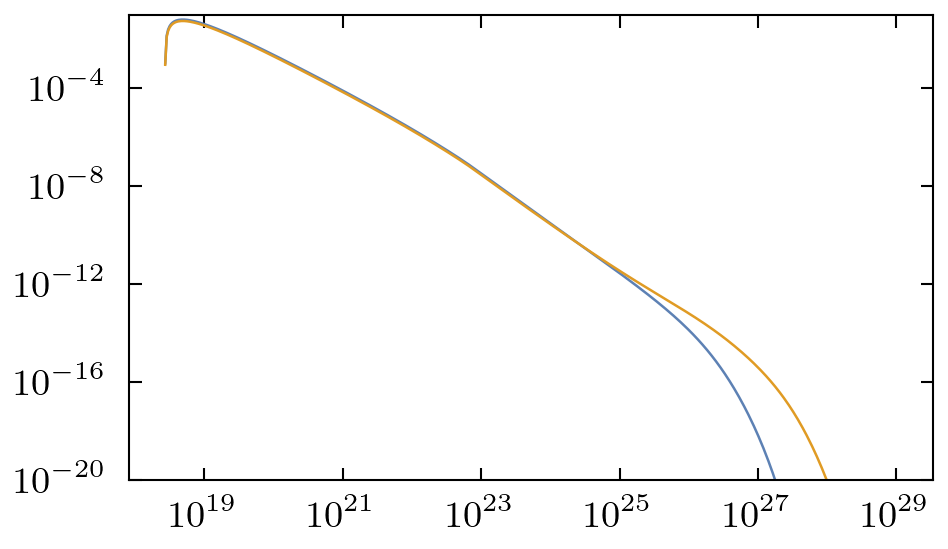

In [140]:
plt.plot(time_bsm, rhoDM_BE(T_dark_bsm, np.zeros(len(T_dark_bsm)), M_s))

plt.plot(time_bsm, 0.5*rhoDM_FD(T_dark_bsm, np.zeros(len(T_dark_bsm)), m_chi))

plt.ylim(1e-20, 1e-1)

plt.yscale('log')
plt.xscale('log')

### HoT Relic Yield

In [122]:
Y_hr = 0.056*(T_dark_bsm[-1]/T_gam_bsm[-1])**3
Y_CDM = 4.5e-7*(1/m_chi)

In [124]:
Y_hr/Y_CDM

0.6440745699311873

In [125]:
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig3_left_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig3_right_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig4_left_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig4_right_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig5_left_Td_by_Tgam.csv')
fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig5_right_Td_by_Tgam.csv')

# fig3_1311_2600_Tnu_by_Tgam = load_csv('../input/fig/1311.2600_fig4_right_Tnu_by_Tgam.csv')
# fig3_1311_2600_Tnu_by_Tgam = load_csv('../input/fig/1311.2600_fig5_left_Tnu_by_Tgam.csv')
# fig3_1311_2600_Tnu_by_Tgam = load_csv('../input/fig/1311.2600_fig5_left_Tnu_by_Tgam.csv')

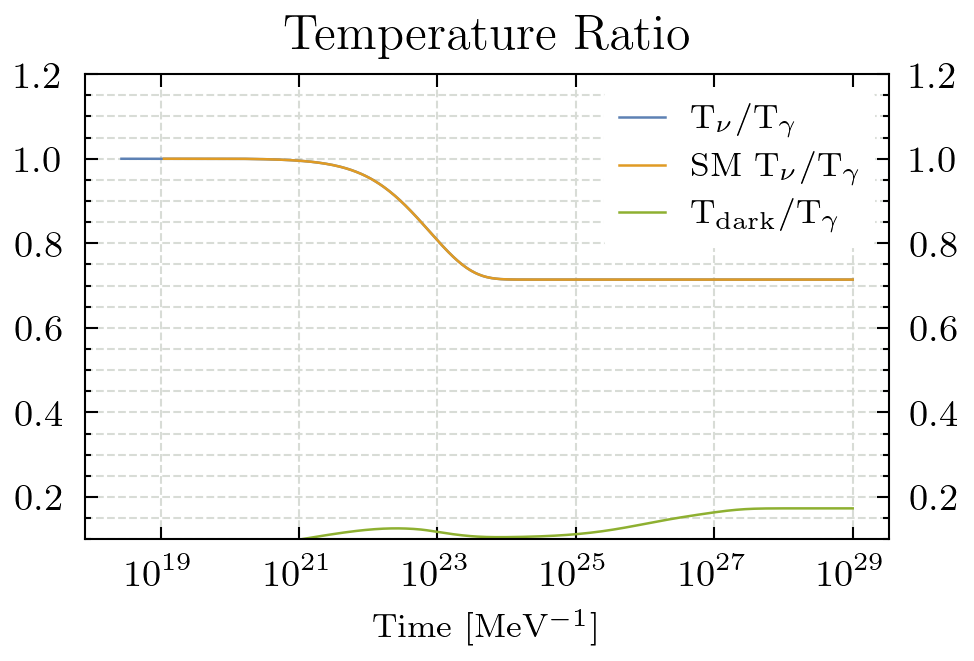

In [126]:
plt.plot(time_bsm, T_nu_bsm/T_gam_bsm, label=r'T$_\nu$/T$_\gamma$')
plt.plot(time_sm, T_nu_sm/T_gam_sm, label=r'SM T$_\nu$/T$_\gamma$')
plt.plot(time_bsm, T_dark_bsm/T_gam_bsm, label=r'T$_{\rm dark}$/T$_\gamma$')
plt.xscale('log')
# plt.yscale('log')

plt.xlabel('Time [MeV$^{-1}$]')

plt.title('Temperature Ratio')

plt.tick_params(labelright=True, which='both')
plt.yticks()
plt.grid(which='both', axis='y')
plt.grid(axis='x')

plt.legend()

# plt.xlim(2e19, 1e29)
plt.ylim(0.1, 1.2)

plt.show()


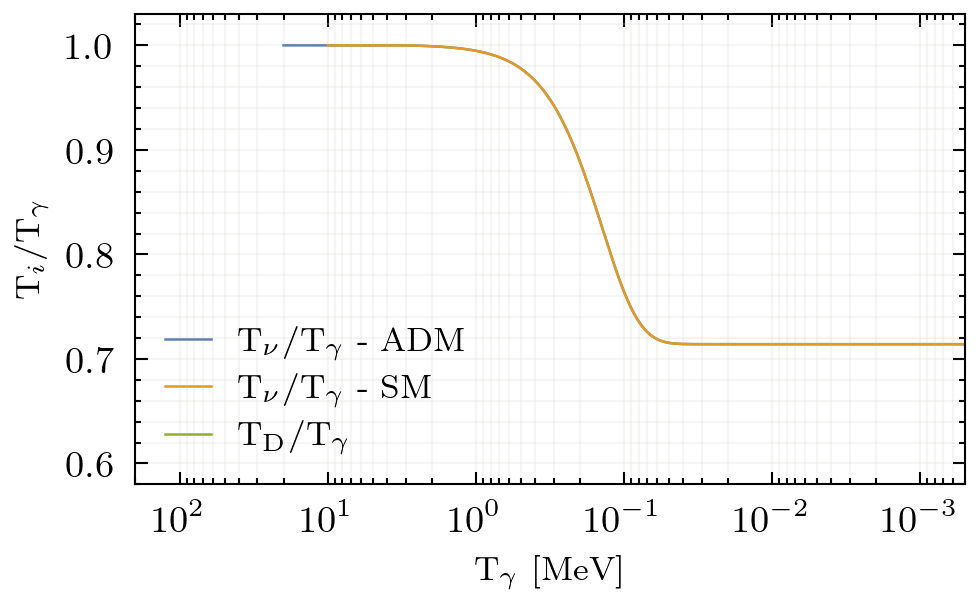

In [127]:
f, ax = plt.subplots(
    1, 1, figsize=(3.25, 2.0), layout="constrained"
)

plt.plot(T_gam_bsm, T_nu_bsm/T_gam_bsm, label=r'T$_\nu$/T$_\gamma$ - ADM')
plt.plot(T_gam_sm, T_nu_sm/T_gam_sm, label=r'T$_\nu$/T$_\gamma$ - SM')
plt.plot(T_gam_bsm, T_dark_bsm/T_gam_bsm, label=r'T$_{\rm D}$/T$_\gamma$')
plt.xscale('log')

# plt.yscale('log')

plt.xlabel('T$_\gamma$ [MeV]')
# plt.title('Temperature Ratio')

# plt.tick_params(labelright=True, which='both')
# plt.yticks()
# plt.grid(which='both', axis='y')
# plt.grid(axis='x')

plt.legend(loc=3, framealpha=0.0)

# plt.xlim(2e19, 1e29)
plt.xlim(5e-4, 2e2)
plt.gca().invert_xaxis()
plt.ylabel(r'T$_{i}$/T$_{\gamma}$')
plt.ylim(0.58, 1.03)
# plt.tight_layout()
plt.grid(which='both', axis='x', linestyle='solid', alpha=0.25)
plt.grid(which='both', axis='y', linestyle='solid', alpha=0.25)
plt.savefig('../output/figures/example_thermal_history_5MeV_1e-5.pdf')

plt.show()

Text(0.5, 0, 'Time [MeV$^{-1}$]')

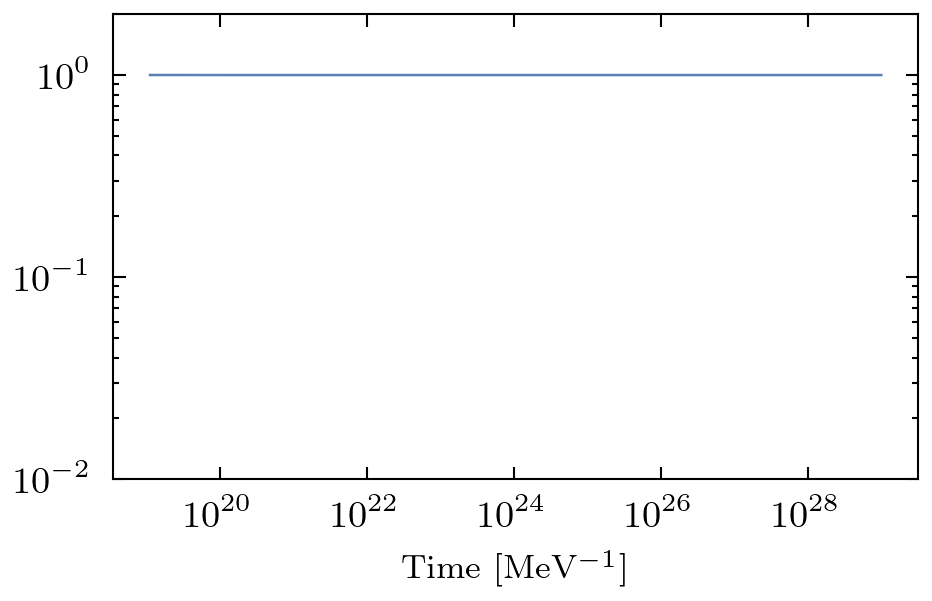

In [128]:
from scipy.interpolate import interp1d
T_gam_SM_I = interp1d(time_sm, T_gam_sm)
T_gam_BSM_I = interp1d(time_bsm, T_gam_bsm)

plt.plot(time_sm, T_gam_BSM_I(time_sm)/T_gam_SM_I(time_sm))
plt.ylim(1e-2, 2)

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Time [MeV$^{-1}$]')


### Baryon-to-photon ratio

In [ ]:
eta_cmb = 6.1e-10

eta_0 = (T_nu_bsm[-1]/T_gam_bsm[-1])**(-3)*eta_cmb
eta = (T_nu_bsm/T_gam_bsm)**3*eta_0

eta_0_sm = (T_nu_sm[-1]/T_gam_sm[-1])**(-3)*eta_cmb
eta_sm = (T_nu_sm/T_gam_sm)**3*eta_0_sm

plt.plot(T_gam_bsm, eta, label='BSM')
plt.plot(T_gam_sm, eta_sm, label='SM')

plt.axvline(0.1, color='black', linestyle='dashed')

plt.xlabel('T [MeV]')
plt.ylabel(r'$\eta_{\rm b}$')

plt.yscale('log')
plt.xscale('log')
plt.gca().invert_xaxis()
plt.legend()
plt.show()


In [ ]:
plt.plot(T_gam_bsm, Boltz.N_eff(T_gam_bsm, T_nu_bsm, T_dark_bsm))
plt.plot(T_gam_sm, Boltz.N_eff_SM(T_gam_sm, T_nu_sm))

plt.xlabel('T [MeV]')
plt.ylabel(r'N$_{\rm eff}$')

plt.xscale('log')
plt.gca().invert_xaxis()

In [ ]:
plt.plot(T_gam_bsm, T_nu_bsm/T_gam_bsm, label=r'T$_\nu$/T$_\gamma$')
plt.plot(T_gam_bsm, T_dark_bsm/T_gam_bsm, label=r'T$_{\rm dark}$/T$_\gamma$')
# plt.plot(*fig3_1311_2600_Td_by_Tgam, label='Vogel & Redondo')
# plt.plot(*fig3_1311_2600_Tnu_by_Tgam, label='Vogel & Redondo - neutrinos')
plt.xscale('log')
# plt.yscale('log')

plt.xlabel('T$_\gamma$ [MeV]')
plt.title(f'Temperature Ratio; {m_de=} MeV; {Q=:.3e}')

plt.tick_params(labelright=True, which='both')
plt.yticks()
plt.grid(which='both', axis='y')
plt.grid(axis='x')
plt.gca().invert_xaxis()


# plt.ylim(0.6, 1.3)
# plt.axvline(200,  color='purple', linestyle='dashed', alpha=0.5, label=r'$\Lambda_{\rm QCD}$')
# plt.axvline(150,  color='purple', linestyle='dashed', alpha=0.5)

plt.axhline((4/11)**(1/3), alpha=0.8, color='gray', linestyle='dotted')
plt.axvline(m_de/20, linestyle='dashed', color='black')
plt.axvline(m_dp, linestyle='dashed', color='black')

# plt.axhline(0.56, alpha=0.8, color='gray', linestyle='dotted')
# plt.axhline(0.46, alpha=0.8, color='gray', linestyle='dotted')

# plt.xlim(1e2, 1.1e-2)
plt.legend()

# plt.savefig('../output/figures/temp_ratio/m_03_eps_6e-9_VR_comparison.png')

plt.show()

In [ ]:
Col_tot = (
    CF_ann_sm_ds(T_gam_bsm, T_dark_bsm, Q)
   +CF_plas(T_gam_bsm, T_dark_bsm, Q)
)

Hub_tot = Boltz.Hubble(T_gam_bsm, T_nu_bsm,T_dark_bsm)*(
    Boltz.rho_DS(T_dark_bsm) + Boltz.p_DS(T_dark_bsm)
)
            

In [ ]:
com_ED = Boltz.rho_DS(T_dark_bsm)*(sf_bsm)**4

com_col = (
   +CF_ann(T_gam_bsm, Q)
   +plas.C_plasmon_forwards(T_gam_bsm, m_de, Q)
)*(sf_bsm)**4

H_plot = Boltz.Hubble(T_gam_bsm, T_nu_bsm, T_dark_bsm)

In [ ]:
# shelton_f2_rho = load_csv('../input/fig/2206.13530_fig2_left_energy.csv')
# shelton_f2_cF = load_csv('../input/fig/2206.13530_fig2_left_CF.csv')

shelton_f2_rho = load_csv('../input/fig/2206.13530_fig2_right_energy.csv')
# shelton_f2_cF = load_csv('../input/fig/2206.13530_fig2_left_CF.csv')

## We need to plot the forward energy transfer term here, which needs to be computed for elastic scattering

In [ ]:
#compute comoving energy density for DeltaNeff = 0.3s

In [ ]:
#calculation of dark sector temp that makes Delta N_eff = 0.3 at Tsm = 1e-3 MeV
r = 0.3*(7/8)*(4/11)**(4/3)*Boltz.rho_EM(1e-3)
T_ds_03 = ((15/np.pi**2)*r)**(1/4)

sf = sf_bsm[find_nearest(T_gam_bsm, 1e-3)]

rho_neff_03 = Boltz.rho_DS(T_ds_03)*(sf)**4

In [ ]:
plt.plot(T_gam_bsm, com_ED)
plt.plot(T_gam_bsm, com_col/H_plot)
# plt.plot(*shelton_f2_rho)
# plt.plot(*shelton_f2_cF)

# plt.axhline(rho_neff_03, label=r'$\Delta N_{\rm eff} = 0.3$', linestyle='dashed')
plt.axhline(1.3e-40, label=r'$\Delta N_{\rm eff} = 0.3$', linestyle='dashed', color='gray')

plt.yscale('log')
plt.xscale('log')
plt.axvline(m_de/4, linestyle='dashed', color='black')

plt.xlabel(r'T$_{\rm sm}$ [MeV]')
plt.ylabel(r'$\rho_{\rm hs} a^4$')

plt.ylim(1e-44, 1e-39)
# plt.xlim(3, 1e4)
plt.xlim(10, 2e6)
plt.show()

In [ ]:
plt.plot(T_gam_bsm, sf_bsm, alpha=0.5)
plt.plot(T_gam_sm, sf_sm, alpha=0.4)


plt.yscale('log')
plt.xscale('log')

## Check Continuity

In [ ]:
def C_forward_de(T, Q):
    return Q**2*(_CF_ff_de_de_I(T))

def C_forward_dp(T, Q):
    return Q**2*(_CF_ff_dp_dp_I(T))

In [ ]:
plt.plot(T_gam_bsm, Boltz.colterms_EM_DS[0](T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='annihilation')
plt.plot(T_gam_bsm, Boltz.colterms_EM_DS[1](T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='scattering')
plt.plot(T_gam_bsm, Boltz.colterms_EM_DS[2](T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='Plasmon Decay')
plt.plot(T_gam_bsm, Boltz.colterms_EM_DS[3](T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='Z decay')

sum_rate = (
    Boltz.colterms_EM_DS[0](T_gam_bsm, T_dark_bsm, Q)
    +Boltz.colterms_EM_DS[1](T_gam_bsm, T_dark_bsm, Q)
    +Boltz.colterms_EM_DS[2](T_gam_bsm, T_dark_bsm, Q)
    +Boltz.colterms_EM_DS[3](T_gam_bsm, T_dark_bsm, Q)
)

ymax = np.max(sum_rate/T_gam_bsm**6)

plt.axvline(m_de, label='Dark Electron', linestyle='dashed', color='darkred')
plt.axvline(m_dp, label='Dark Proton', linestyle='dashed', color='darkblue')



plt.xscale('log')
plt.yscale('log')
# plt.ylim(1e-5*ymax, 20*ymax)
# plt.xlim(5e-1, 5)
plt.gca().invert_xaxis()

plt.xlabel(r'T$_\gamma$ [MeV]')
plt.title(r'C/$T^6_\gamma$ [MeV$^{-1}$]')
plt.legend()

In [ ]:
T_gam_test = 6
T_ds_test = 5.99
print(Boltz.colterms_EM_DS[0](T_gam_test, T_ds_test, Q))
print(Boltz.colterms_EM_DS[1](T_gam_test, T_ds_test, Q))


In [ ]:
plt.plot(T_gam_bsm,np.abs(sum_rate)/T_gam_bsm**6, label='annihilation')

ymax = np.max(sum_rate/T_gam_bsm**6)

plt.axvline(m_de, label='Dark Electron', linestyle='dashed', color='darkred')
plt.axvline(m_dp, label='Dark Proton', linestyle='dashed', color='darkblue')



plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5*ymax, 20*ymax)
plt.gca().invert_xaxis()

plt.xlabel(r'T$_\gamma$ [MeV]')
plt.title(r'C/$T^6_\gamma$ [MeV$^{-1}$]')
plt.legend()

In [ ]:
Boltz.colterms_EM_DS[3](T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6

In [26]:
import mcp_boltzmann.natural_units as nu

In [28]:
0.25*8.5*1e-27*nu.kg/(nu.meter)**3

9.159030494863801e-48

In [30]:
33*nu.eV*2*1.2/(np.pi**2)*(0.2087)**3*(2.7*nu.Kelvin)**3

0.10031197701261979

In [31]:
rho_C = 8.5*1e-27*nu.kg/(nu.meter)**3

In [32]:
rho_DM = 0.25*rho_C

In [33]:
rho_WDM = 33*nu.eV*2*1.2/(np.pi**2)*(0.2087)**3*(2.7*nu.Kelvin)**3

In [36]:
rho_WDM/rho_DM

0.10031197701261979

In [37]:
rho_WDM

9.187604564586614e-49

In [38]:
3.66*0.25

0.915

In [185]:
s_0 = (2*(2*np.pi**2/45)*(2.7*nu.Kelvin)**3 + 6*(7/8)*(2*np.pi**2/45)*(0.71644*2.7*nu.Kelvin)**3)

In [186]:
(0.25*3.66e-47)/(10*nu.keV*s_0)

4.2133964411710144e-05

In [187]:
s_0

2.1716446880220398e-38

In [28]:
0.097*(2.7*nu.Kelvin)**3

1.2217468999209737e-39